
## **Processing Raw Dataset to Processed Dataset**

In [5]:
import cv2
import os
import shutil
import numpy as np
from ultralytics import YOLO

def process_subject_folder_to_silhouettes(
    input_folder="new raw dataset/Ankit", 
    output_folder="live_test_folder", 
    img_size=(64, 64),
    
    # === TWEAK THESE PARAMETERS ===
    inference_size=1080,        # Increase to 1280 or 1920 for maximum sharpness (runs slower)
    confidence_threshold=0.8,   # Increase to 0.6 or 0.7 for stricter, cleaner edges
    extract_every_n_frame=3     # 1 = 30 FPS, 2 = 15 FPS, 3 = 10 FPS, 6 = 5 FPS
    # ==============================
):
    # 1. Clean and prepare the output folder once
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)
    os.makedirs(output_folder)
    
    # 2. Load the YOLO model once for all videos
    print("Loading YOLOv8 Segmentation Model...")
    model = YOLO("yolov8n-seg.pt")
    
    total_saved_count = 0
    
    # 3. Iterate through every file in the subject's folder
    valid_extensions = ('.mp4', '.avi', '.mov', '.mkv')
    video_files = [f for f in os.listdir(input_folder) if f.lower().endswith(valid_extensions)]
    
    if not video_files:
        print(f"No video files found in {input_folder}")
        return

    print(f"Found {len(video_files)} videos in '{input_folder}'. Starting processing...\n")

    for video_name in video_files:
        video_path = os.path.join(input_folder, video_name)
        video_base_name = os.path.splitext(video_name)[0] # Get name without extension
        
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error: Could not open {video_path}. Skipping.")
            continue
            
        frame_count = 0
        video_saved_count = 0
        print(f"Processing '{video_name}'...")

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: 
                break
                
            frame_count += 1
            
            # Frame Skipping Logic
            if frame_count % extract_every_n_frame != 0:
                continue
            
            # YOLO Inference
            results = model.predict(
                frame, 
                classes=[0], 
                retina_masks=True, 
                imgsz=inference_size, 
                conf=confidence_threshold,
                verbose=False
            )
            
            binary_silhouette = np.zeros((frame.shape[0], frame.shape[1]), dtype=np.uint8)
            
            for r in results:
                if r.masks is not None:
                    mask_data = r.masks.data[0].cpu().numpy()
                    binary_silhouette = np.maximum(binary_silhouette, (mask_data > 0.5).astype(np.uint8) * 255)

            if np.sum(binary_silhouette) > 0:
                x, y, w, h = cv2.boundingRect(binary_silhouette)
                
                pad_w = int(w * 0.10)
                pad_h = int(h * 0.10)
                
                x1 = max(x - pad_w, 0)
                y1 = max(y - pad_h, 0)
                x2 = min(x + w + pad_w, frame.shape[1])
                y2 = min(y + h + pad_h, frame.shape[0])
                
                cropped_person = binary_silhouette[y1:y2, x1:x2]
                final_silhouette = cv2.resize(cropped_person, img_size)
                
                # Save with a smart name: videoName_frame_0001.png
                save_filename = f"{video_base_name}_frame_{video_saved_count:04d}.png"
                save_path = os.path.join(output_folder, save_filename)
                
                cv2.imwrite(save_path, final_silhouette)
                video_saved_count += 1
                total_saved_count += 1

        cap.release()
        print(f"  -> Extracted {video_saved_count} silhouettes from '{video_name}'.")

    print(f"\n[SUCCESS] Finished folder! Extracted a total of {total_saved_count} silhouettes to '{output_folder}'.")

if __name__ == "__main__":
    current_dir = os.getcwd()
    
    # Point this to the folder containing all videos of the subject
    absolute_input_folder = os.path.join(current_dir, r"D:\vit study\Machine Learning\Gait\test1") 
    absolute_output_folder = os.path.join(current_dir, r"D:\vit study\Machine Learning\Gait\new test")
    
    process_subject_folder_to_silhouettes(
        input_folder=absolute_input_folder, 
        output_folder=absolute_output_folder, 
        img_size=(64, 64),
        inference_size=1080,       
        extract_every_n_frame=2
    )

Loading YOLOv8 Segmentation Model...
Found 1 videos in 'D:\vit study\Machine Learning\Gait\test1'. Starting processing...

Processing '1.mp4'...
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be m

## **Splitting Processed Dataset into train and validation**

In [24]:
import os
import shutil
import random
from collections import defaultdict

def reorganize_dataset(source_root, output_root, validation_split=0.3, random_seed=42):
    """
    CUSTOM DATASET VERSION
    
    Reorganize custom dataset by:
    - Reading all subject folders (regardless of name/number)
    - Splitting images into train/validation (30% validation, 70% training)
    - Organizing by person folder
    - No overlapping between splits
    """

    random.seed(random_seed)

    # Create output directories
    train_root = os.path.join(output_root, 'train')
    validation_root = os.path.join(output_root, 'validation')

    os.makedirs(train_root, exist_ok=True)
    os.makedirs(validation_root, exist_ok=True)

    print(f"Source root: {source_root}")
    print(f"Output root: {output_root}")
    print(f"Validation split: {validation_split * 100}%")
    print("-" * 60)
    print()

    # Get all person folders (Removed the .isdigit() constraint)
    all_items = os.listdir(source_root)
    person_folders = sorted([
        item for item in all_items 
        if os.path.isdir(os.path.join(source_root, item))
    ])

    print(f"Found {len(person_folders)} subject folders: {', '.join(person_folders)}")
    print("-" * 60)
    print()

    # Dictionary to store all images per person
    person_images = defaultdict(list)

    # Walk through each person folder
    for person_name in person_folders:
        person_path = os.path.join(source_root, person_name)

        # Collect all images from this person 
        for root, dirs, files in os.walk(person_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    full_path = os.path.join(root, file)
                    person_images[person_name].append(full_path)

    # Print summary
    total_images = sum(len(images) for images in person_images.values())
    if total_images == 0:
        print("ERROR: No images found! Please check your source_root path.")
        return None, None
        
    print(f"Total images collected: {total_images:,}")
    print(f"Subjects with images: {len(person_images)}")
    print()
    print("Processing and splitting images:")
    print("-" * 60)

    # Process each person's images
    stats = {'train': 0, 'validation': 0, 'persons_processed': 0}

    for person_name in sorted(person_images.keys()):
        images = person_images[person_name]
        num_images = len(images)

        if num_images == 0:
            continue

        # Randomly shuffle images for this person
        random.shuffle(images)

        # Calculate split point
        split_point = int(num_images * validation_split)

        # Note: validation takes the first portion, train takes the rest
        validation_images = images[:split_point]
        train_images = images[split_point:]

        # Create person folders in train and validation directories
        train_person_dir = os.path.join(train_root, person_name)
        validation_person_dir = os.path.join(validation_root, person_name)

        os.makedirs(train_person_dir, exist_ok=True)
        os.makedirs(validation_person_dir, exist_ok=True)

        # Copy images to train folder
        for img_path in train_images:
            filename = os.path.basename(img_path)
            dest_path = os.path.join(train_person_dir, filename)
            shutil.copy2(img_path, dest_path)
            stats['train'] += 1

        # Copy images to validation folder
        for img_path in validation_images:
            filename = os.path.basename(img_path)
            dest_path = os.path.join(validation_person_dir, filename)
            shutil.copy2(img_path, dest_path)
            stats['validation'] += 1

        stats['persons_processed'] += 1

        # Print progress for each person
        val_count = len(validation_images)
        train_count = len(train_images)
        val_pct = (val_count / num_images) * 100 if num_images > 0 else 0

        print(f"Subject '{person_name}': Total={num_images:6,d} | Train={train_count:6,d} | Val={val_count:6,d} ({val_pct:.1f}%)")

    # Print summary statistics
    print()
    print("=" * 60)
    print("REORGANIZATION COMPLETE")
    print("=" * 60)
    print(f"Subjects processed: {stats['persons_processed']}")
    print(f"Total images in training: {stats['train']:,}")
    print(f"Total images in validation: {stats['validation']:,}")
    print(f"Total images processed: {stats['train'] + stats['validation']:,}")

    if stats['train'] + stats['validation'] > 0:
        actual_val_pct = (stats['validation'] / (stats['train'] + stats['validation'])) * 100
        print(f"Actual validation split: {actual_val_pct:.2f}%")

    print()
    print(f"Train directory: {train_root}")
    print(f"Validation directory: {validation_root}")
    print()

    return train_root, validation_root


if __name__ == "__main__":
    # Ensure these paths match your system
    SOURCE_DATASET = r"D:\Study\Coding\Project\GAIT_2\New Dataset\processed"
    OUTPUT_DIRECTORY = r"D:\Study\Coding\Project\GAIT_2\New Dataset"

    train_dir, val_dir = reorganize_dataset(
        source_root=SOURCE_DATASET,
        output_root=OUTPUT_DIRECTORY,
        validation_split=0.3, # 30% for validation, 70% for training
        random_seed=42
    )

Source root: D:\Study\Coding\Project\GAIT_2\New Dataset\processed
Output root: D:\Study\Coding\Project\GAIT_2\New Dataset
Validation split: 30.0%
------------------------------------------------------------

Found 10 subject folders: Adarsh, Aditi, Aman, Ankit, Himanshu, Jyotibrat, Kunal, Swayam, Tiwari, Ujjwal
------------------------------------------------------------

Total images collected: 7,760
Subjects with images: 10

Processing and splitting images:
------------------------------------------------------------
Subject 'Adarsh': Total=   716 | Train=   502 | Val=   214 (29.9%)
Subject 'Aditi': Total=   731 | Train=   512 | Val=   219 (30.0%)
Subject 'Aman': Total=   870 | Train=   609 | Val=   261 (30.0%)
Subject 'Ankit': Total=   796 | Train=   558 | Val=   238 (29.9%)
Subject 'Himanshu': Total=   741 | Train=   519 | Val=   222 (30.0%)
Subject 'Jyotibrat': Total=   866 | Train=   607 | Val=   259 (29.9%)
Subject 'Kunal': Total=   712 | Train=   499 | Val=   213 (29.9%)
Subjec

## **Training Xception model**

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import os
import time
import json
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast

# === UPDATE THIS TO YOUR NEW DATASET FOLDER ===
DATA_DIR = r"D:\Study\Coding\Project\GAIT_2\New Dataset" 

BATCH_SIZE = 64
NUM_EPOCHS = 20 
LEARNING_RATE = 0.001

def train_gait_model():
    print(f"Initializing custom training process...")

    # --- Set up Data Transformations ---
    data_transforms = {
        'train': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'validation': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
    }

    # --- Load the Datasets ---
    train_dir = os.path.join(DATA_DIR, 'train')
    validation_dir = os.path.join(DATA_DIR, 'validation')

    print(f"Loading data from: {DATA_DIR}")
    
    train_dataset = datasets.ImageFolder(train_dir, data_transforms['train'])
    val_dataset = datasets.ImageFolder(validation_dir, data_transforms['validation'])

    class_names = train_dataset.classes
    num_classes = len(class_names)
    print(f"\nFound {num_classes} subjects: {class_names}")

    # --- CRITICAL: Save the class mapping for real-time testing later ---
    mapping_path = 'class_mapping.json'
    with open(mapping_path, 'w') as f:
        json.dump(train_dataset.class_to_idx, f)
    print(f"Saved class mapping to {mapping_path}")

    # --- Create DataLoaders ---
    dataloaders = {
        'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True),
        'validation': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    }

    dataset_sizes = {'train': len(train_dataset), 'validation': len(val_dataset)}
    print(f"Training images: {dataset_sizes['train']}")
    print(f"Validation images: {dataset_sizes['validation']}\n")

    # --- Build the Xception Model using TIMM ---
    print("Loading Xception model via TIMM...")
    model = timm.create_model('xception', pretrained=True, num_classes=num_classes)

    # --- Set up for Training ---
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Training will use device: {device}\n")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    scaler = GradScaler()
    use_amp = torch.cuda.is_available()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # --- Early Stopping Variables ---
    patience = 4  
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    # We define the save path here so the loop knows where to put it
    model_save_path = 'new_dataset_gait_xception_FULL.pth'

    # --- Start the Training Loop ---
    start_time = time.time()
    
    for epoch in range(NUM_EPOCHS):
        print(f'Epoch {epoch+1}/{NUM_EPOCHS}')
        print('-' * 10)

        for phase in ['train', 'validation']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            progress_bar = tqdm(dataloaders[phase], desc=f'{phase.capitalize()} Phase')
            
            for inputs, labels in progress_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad(set_to_none=True)

                with autocast(enabled=use_amp):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                
                _, preds = torch.max(outputs, 1)

                if phase == 'train':
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}\n')

            # --- Metrics & Early Stopping Logic ---
            acc_value = epoch_acc.item() 
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(acc_value)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(acc_value)

                # ---> CHANGED: Save the ENTIRE model directly to disk on a new best <---
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    epochs_no_improve = 0
                    torch.save(model, model_save_path)
                else:
                    epochs_no_improve += 1
                    print(f"[INFO] Validation loss did not improve. Patience: {epochs_no_improve}/{patience}")

        # Trigger Early Stopping Break
        if epochs_no_improve >= patience:
            print(f"\n[EARLY STOPPING] Triggered! Training halted at Epoch {epoch+1}.")
            break

    time_elapsed = time.time() - start_time
    print(f"\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Validation Loss Achieved: {best_val_loss:.4f}")
    print(f"The best performing model is securely saved as '{model_save_path}'.")

    # Save the history separately
    history_file = 'training_history.json'
    with open(history_file, 'w') as f:
        json.dump(history, f)
    print(f"Training history saved permanently to '{history_file}'")
    
    return history 

if __name__ == '__main__':
    history = train_gait_model()

Initializing custom training process...
Loading data from: D:\Study\Coding\Project\GAIT_2\New Dataset

Found 10 subjects: ['Adarsh', 'Aditi', 'Aman', 'Ankit', 'Himanshu', 'Jyotibrat', 'Kunal', 'Swayam', 'Tiwari', 'Ujjwal']
Saved class mapping to class_mapping.json
Training images: 5437
Validation images: 2323

Loading Xception model via TIMM...


C:\Users\swaya\AppData\Local\Temp\ipykernel_9640\3187377803.py:76: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Training will use device: cuda:0

Epoch 1/20
----------


Train Phase:   0%|          | 0/85 [00:00<?, ?it/s]C:\Users\swaya\AppData\Local\Temp\ipykernel_9640\3187377803.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Train Phase:   1%|          | 1/85 [00:11<16:28, 11.77s/it]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000001E4313A8CC0>
Traceback (most recent call last):
  File "d:\Study\Coding\Project\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "d:\Study\Coding\Project\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1562, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'
Train Phase: 100%|██████████| 85/85 [00:21<00:00,  4.03it/s]


Train Loss: 2.0100 Acc: 0.2695



...

Validation Loss: 0.3440 Acc: 0.9156

[INFO] Validation loss did not improve. Patience: 3/4
Epoch 19/20
----------


Train Phase: 100%|██████████| 85/85 [00:22<00:00,  3.84it/s]


Train Loss: 0.0420 Acc: 0.9846



Validation Phase: 100%|██████████| 37/37 [00:14<00:00,  2.58it/s]

Validation Loss: 0.3347 Acc: 0.9195

[INFO] Validation loss did not improve. Patience: 4/4

[EARLY STOPPING] Triggered! Training halted at Epoch 19.

Training complete in 11m 16s
Best Validation Loss Achieved: 0.2161
The best performing model is securely saved as 'new_dataset_gait_xception_FULL.pth'.
Training history saved permanently to 'training_history.json'


## **Visualizations**

Graph saved successfully as 'training_curves.png'


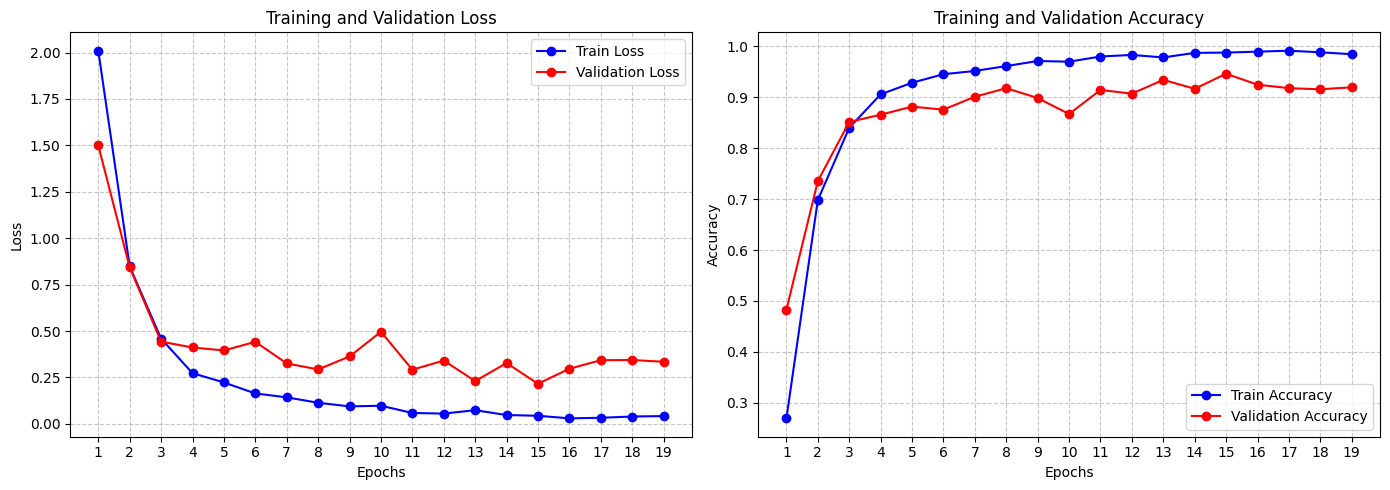

In [28]:
import json
import matplotlib.pyplot as plt

# 1. Load the saved history from the JSON file
with open('training_history.json', 'r') as f:
    history = json.load(f)

# Calculate the number of epochs dynamically based on the data
epochs = range(1, len(history['train_loss']) + 1)

# 2. Set up the plotting canvas
plt.figure(figsize=(14, 5))

# --- Plot 1: Training vs Validation Loss ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(epochs, history['val_loss'], label='Validation Loss', color='red', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs) # Forces the x-axis to show whole numbers
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Training vs Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='Train Accuracy', color='blue', marker='o')
plt.plot(epochs, history['val_acc'], label='Validation Accuracy', color='red', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Save the graph as an image and display it
plt.tight_layout()
plt.savefig('training_curves.png')
print("Graph saved successfully as 'training_curves.png'")

plt.show()

[SYSTEM] Using device: cuda:0

[SYSTEM] Analyzing validation data and generating heatmap... Please wait.


C:\Users\swaya\AppData\Local\Temp\ipykernel_9640\986544351.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('Models/new_dataset_gait_xception_FULL.pth

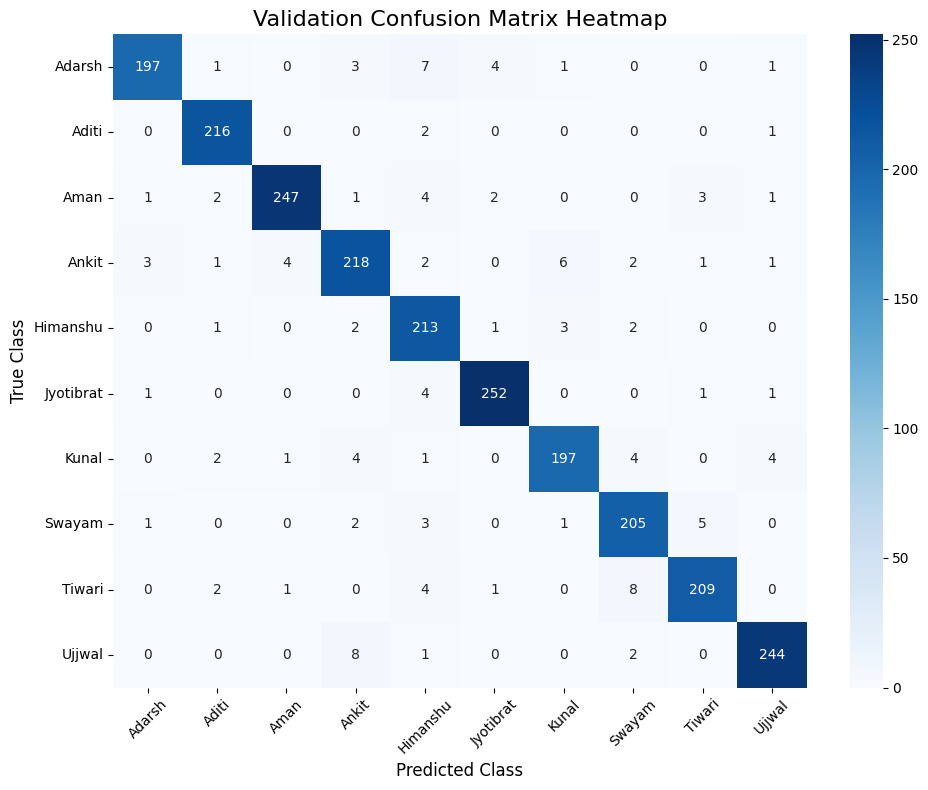

In [29]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# --- NEW IMPORTS FOR THE HEATMAP ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. THE HEATMAP GENERATOR FUNCTION
# ==========================================
def generate_heatmap(model, dataloader, device, class_names):
    print("\n[SYSTEM] Analyzing validation data and generating heatmap... Please wait.")
    model.eval() # Freeze model weights for inference
    
    all_preds = []
    all_labels = []

    # Iterate through the validation data
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot the matrix using Seaborn
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title('Validation Confusion Matrix Heatmap', fontsize=16)
    plt.ylabel('True Class', fontsize=12)
    plt.xlabel('Predicted Class', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==========================================
# 2. THE MAIN EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # Set up device
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"[SYSTEM] Using device: {device}")

    # Load the trained model
    model = torch.load('Models/new_dataset_gait_xception_FULL.pth', map_location=device)
    model = model.to(device)

    # Set up validation data transforms
    data_transforms = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    validation_dir = r"D:\Study\Coding\Project\GAIT_2\New Dataset\validation"
    val_dataset = datasets.ImageFolder(validation_dir, data_transforms)
    
    # Note: On Windows, num_workers > 0 can sometimes cause freezing. 
    # If it hangs, change num_workers=0.
    dataloaders_val = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

    # Extract the class names dynamically from your folders
    my_class_names = val_dataset.classes

    # Now generate the heatmap!
    generate_heatmap(model, dataloaders_val, device, my_class_names)

Loading model on cuda:0...
Evaluating validation images for ROC curve...


C:\Users\swaya\AppData\Local\Temp\ipykernel_9640\1835569744.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('Models/new_dataset_gait_xception_FULL.pt

Success! Graph saved as 'roc_auc_curve.png'


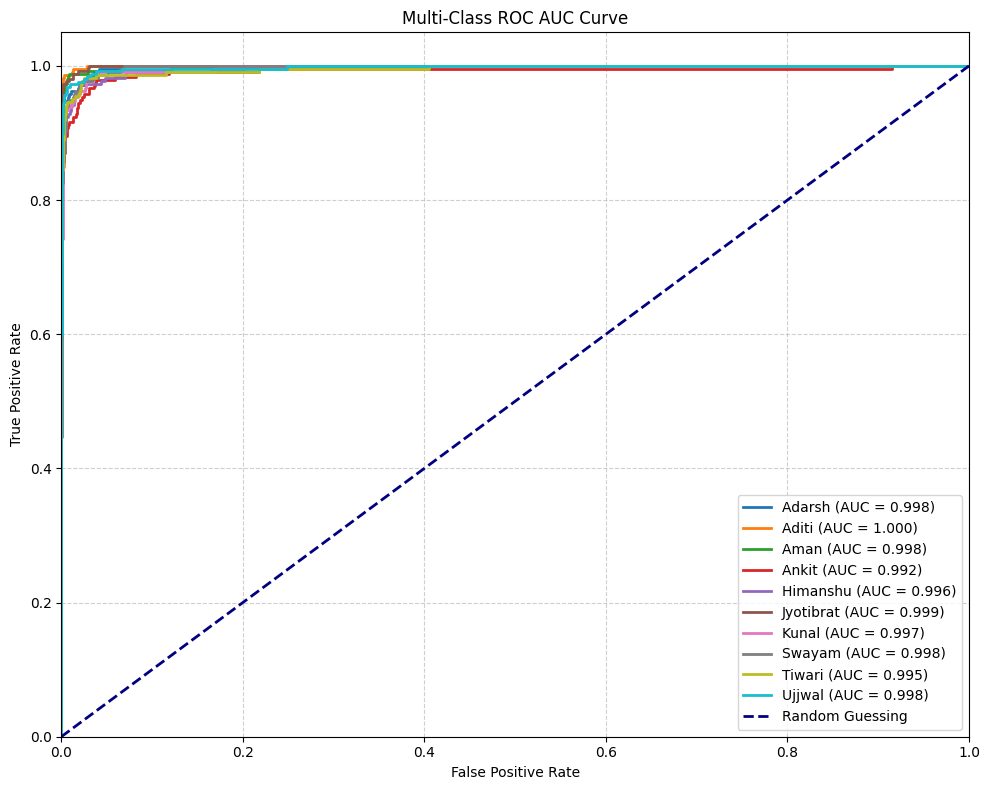

In [31]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import os
import json

def generate_roc_auc_curve():
    # 1. Recreate the Validation DataLoader
    DATA_DIR = r"D:\Study\Coding\Project\GAIT_2\New Dataset"
    validation_dir = os.path.join(DATA_DIR, 'validation')
    
    val_transforms = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])
    
    val_dataset = datasets.ImageFolder(validation_dir, val_transforms)
    val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)

    # 2. Load your saved model and class names
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Loading model on {device}...")
    
    model = torch.load('Models/new_dataset_gait_xception_FULL.pth', map_location=device)
    model.to(device)
    model.eval() # CRITICAL for evaluation

    try:
        with open('class_mapping.json', 'r') as f:
            class_map = json.load(f)
            class_names = [k for k, v in sorted(class_map.items(), key=lambda item: item[1])]
    except FileNotFoundError:
        class_names = val_dataset.classes

    num_classes = len(class_names)

    # 3. Gather predictions
    print("Evaluating validation images for ROC curve...")
    y_true = []
    y_scores = []

    with torch.no_grad():
        for inputs, labels in val_dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            
            # Convert raw outputs to percentage probabilities
            probabilities = F.softmax(outputs, dim=1)
            
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(probabilities.cpu().numpy())

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    # 4. Prepare data for Multi-Class ROC
    y_true_bin = label_binarize(y_true, classes=range(num_classes))
    if num_classes == 2:
        y_true_bin = np.hstack((1 - y_true_bin, y_true_bin))

    # 5. Plot the ROC Curve
    plt.figure(figsize=(10, 8))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

    # Plot the random guessing line
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC AUC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig('roc_auc_curve.png')
    print("Success! Graph saved as 'roc_auc_curve.png'")
    
    plt.show()

# Run it!
generate_roc_auc_curve()

## **Majority Voting Testing**

In [2]:
import torch
from torchvision import transforms
from PIL import Image
from pathlib import Path
from collections import Counter
import json

def get_majority_vote(folder_path, model, device, class_names):
    folder_path = Path(folder_path)
    
    # Grab all images directly in this folder
    image_paths = list(folder_path.glob("*.png")) + list(folder_path.glob("*.jpg")) + list(folder_path.glob("*.jpeg"))

    if not image_paths:
        print(f"No images found in {folder_path}!")
        return None

    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    predicted_indices = []

    # Run predictions on every image
    with torch.no_grad():
        for img_path in image_paths:
            img = Image.open(img_path).convert('RGB')
            tensor = transform(img).unsqueeze(0).to(device)
            
            outputs = model(tensor)
            _, pred = torch.max(outputs, 1)
            pred_idx = pred.item()
            predicted_indices.append(pred_idx)
            
            # Print the prediction for each individual image
            predicted_subject_name = class_names[pred_idx]
            print(f"Image {img_path.name} predicted as {predicted_subject_name}")

    if not predicted_indices:
        return None

    # Tally the votes
    counter = Counter(predicted_indices)
    most_common_idx, count = counter.most_common(1)[0]
    predicted_subject = class_names[most_common_idx]

    # Print the exact final summary format
    print(f"\nMost frequent predicted subject across folder: {predicted_subject} (predicted {count} times)")
    print(f"Final subject prediction: {predicted_subject}")
    
    return predicted_subject


def run_evaluation(model_path, test_directory):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Processing on: {device}")

    # 1. Load the Model
    try:
        model = torch.load(model_path, map_location=device, weights_only=False)
        model.to(device)
        model.eval()
    except FileNotFoundError:
        print(f"Error: Could not find '{model_path}'. Please check the path.")
        return

    # 2. Load Class Names
    try:
        with open('class_mapping.json', 'r') as f:
            class_map = json.load(f)
            class_names = [k for k, v in sorted(class_map.items(), key=lambda item: item[1])]
    except FileNotFoundError:
        print("Error: 'class_mapping.json' not found in the current directory.")
        return

    print("\n" + "="*50)
    print(f"Evaluating Folder: {test_directory}")
    print("="*50 + "\n")

    # 3. Run the voting function
    get_majority_vote(test_directory, model, device, class_names)

In [4]:
# Insert your model file name/path
MODEL_PATH = "Models/new_dataset_gait_xception_FULL.pth"

# Insert the path to the folder containing your test images
TEST_FOLDER_PATH = r"D:\vit study\Machine Learning\Gait\processed_subject_4"

# Run the evaluation
run_evaluation(MODEL_PATH, TEST_FOLDER_PATH)

Processing on: cuda:0

Evaluating Folder: D:\vit study\Machine Learning\Gait\processed_subject_4

Image frame_0000.png predicted as Swayam
Image frame_0001.png predicted as Swayam
Image frame_0002.png predicted as Swayam
Image frame_0003.png predicted as Swayam
Image frame_0004.png predicted as Swayam
Image frame_0005.png predicted as Swayam
Image frame_0006.png predicted as Swayam
Image frame_0007.png predicted as Swayam
Image frame_0008.png predicted as Swayam
Image frame_0009.png predicted as Swayam
Image frame_0010.png predicted as Swayam
Image frame_0011.png predicted as Swayam
Image frame_0012.png predicted as Swayam
Image frame_0013.png predicted as Swayam
Image frame_0014.png predicted as Swayam
Image frame_0015.png predicted as Swayam
Image frame_0016.png predicted as Swayam
Image frame_0017.png predicted as Swayam
Image frame_0018.png predicted as Swayam
Image frame_0019.png predicted as Swayam
Image frame_0020.png predicted as Swayam
Image frame_0021.png predicted as Swayam


## **Capturing live subject, processing and storing the silhouettes**

In [1]:
import cv2
import time
import threading
import os
import shutil
import numpy as np
from ultralytics import YOLO

# ==========================================
# 1. THE PREPROCESSING FUNCTION (Extracts Silhouettes)
# ==========================================
def process_video_to_silhouettes_custom(
    video_path="temp_gait.avi", 
    output_folder="live_test_folder", 
    img_size=(64, 64),
    
    # === TWEAK THESE PARAMETERS ===
    inference_size=1080,        
    confidence_threshold=0.7,   
    extract_every_n_frame=2     
    # ==============================
):
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)
    os.makedirs(output_folder)
    
    print("Loading YOLOv8 Segmentation Model...")
    model = YOLO("yolov8n-seg.pt")
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open {video_path}")
        return
        
    frame_count = 0
    saved_count = 0
    print(f"Processing video with Inference Size: {inference_size}, saving every {extract_every_n_frame} frames...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: 
            break
            
        frame_count += 1
        
        if frame_count % extract_every_n_frame != 0:
            continue
        
        results = model.predict(
            frame, 
            classes=[0], 
            retina_masks=True, 
            imgsz=inference_size, 
            conf=confidence_threshold,
            verbose=False
        )
        
        binary_silhouette = np.zeros((frame.shape[0], frame.shape[1]), dtype=np.uint8)
        
        for r in results:
            if r.masks is not None:
                mask_data = r.masks.data[0].cpu().numpy()
                binary_silhouette = np.maximum(binary_silhouette, (mask_data > 0.5).astype(np.uint8) * 255)

        if np.sum(binary_silhouette) > 0:
            x, y, w, h = cv2.boundingRect(binary_silhouette)
            
            pad_w = int(w * 0.10)
            pad_h = int(h * 0.10)
            
            x1 = max(x - pad_w, 0)
            y1 = max(y - pad_h, 0)
            x2 = min(x + w + pad_w, frame.shape[1])
            y2 = min(y + h + pad_h, frame.shape[0])
            
            cropped_person = binary_silhouette[y1:y2, x1:x2]
            final_silhouette = cv2.resize(cropped_person, img_size)
            
            save_path = os.path.join(output_folder, f"frame_{saved_count:04d}.png")
            cv2.imwrite(save_path, final_silhouette)
            saved_count += 1

    cap.release()
    print(f"\n[SUCCESS] Extracted {saved_count} perfectly spaced silhouettes to '{output_folder}'!")


# ==========================================
# 2. THE MAIN CAMERA ENGINE
# ==========================================
def auto_capture_always_on_threaded_phone():
    # 1. Connected to Phone Camera (Index 1) and forced to True 1080p
    cap = cv2.VideoCapture(1, cv2.CAP_DSHOW)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)
    
    # Notice: Manual exposure lines are completely removed so your phone's ISP handles the lighting perfectly.
    
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # ==========================================
    # THE HARDWARE AUTO-BENCHMARK
    # ==========================================
    print(f"\n[SYSTEM] Benchmarking camera hardware at {width}x{height}... Please wait 2 seconds.")
    start_time = time.time()
    for _ in range(20): 
        cap.read()
    elapsed_time = time.time() - start_time
    
    true_fps = 20 / elapsed_time
    print(f"[SYSTEM] Hardware benchmark complete. Actual Camera Speed: {true_fps:.1f} FPS")
    
    frames_to_capture = int(true_fps * 5.0)    
    dynamic_skip = max(1, round(true_fps / 10.0))
    
    print(f"[SYSTEM] -> Setting capture limit to {frames_to_capture} frames.")
    print(f"[SYSTEM] -> Setting extraction skip rate to {dynamic_skip}.")
    # ==========================================
    
    zone_w = int(width * 0.60)
    zone_h = int(height * 1.0)
    zx1 = int((width - zone_w) / 2)
    zy1 = 0; zx2 = zx1 + zone_w; zy2 = height
    
    print("\n[SYSTEM] Loading fast Watcher model...")
    watcher_model = YOLO("yolov8n.pt")
    
    state = "WAITING"
    frames_captured = 0
    subject_counter = 1
    cooldown_frames = 0
    
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = None
    filename = ""

    print("\n[READY] Phone Camera Live. Waiting for subject...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        display_frame = frame.copy()

        if state == "WAITING":
            if cooldown_frames > 0:
                cooldown_frames -= 1
                cv2.putText(display_frame, "PROCESSING PREVIOUS...", (zx1 + 10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
            else:
                results = watcher_model.predict(frame, classes=[0], verbose=False)
                person_in_zone = False

                for r in results:
                    for box in r.boxes:
                        px1, py1, px2, py2 = map(int, box.xyxy[0])
                        if not (px2 < zx1 or px1 > zx2 or py2 < zy1 or py1 > zy2):
                            person_in_zone = True
                            break

                cv2.rectangle(display_frame, (zx1, zy1), (zx2, zy2), (255, 0, 0), 2)
                cv2.putText(display_frame, "WAITING FOR SUBJECT...", (zx1 + 10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

                if person_in_zone:
                    print(f"\n[TRIGGER] Subject detected! Capturing for 5 seconds...")
                    state = "CAPTURING"
                    frames_captured = 0
                    filename = f"live_subject_{subject_counter}.avi"
                    out = cv2.VideoWriter(filename, fourcc, true_fps, (width, height))

        elif state == "CAPTURING":
            out.write(frame)
            frames_captured += 1
            
            cv2.rectangle(display_frame, (zx1, zy1), (zx2, zy2), (0, 0, 255), 4)
            cv2.putText(display_frame, f"CAPTURING: {frames_captured}/{frames_to_capture}", (zx1 + 10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)

            if frames_captured >= frames_to_capture:
                print(f"[SUCCESS] Saved {filename}")
                out.release()
                
                folder_name = f"processed_subject_{subject_counter}"
                
                worker = threading.Thread(
                    target=process_video_to_silhouettes_custom, 
                    kwargs={
                        "video_path": filename,
                        "output_folder": folder_name,
                        "img_size": (64, 64), # <--- Kept exactly at 64x64
                        "inference_size": 1088,  # <--- BUMPED TO 1088 to process the new 1080p video properly
                        "confidence_threshold": 0.7,
                        "extract_every_n_frame": dynamic_skip 
                    }
                )
                worker.start()
                
                subject_counter += 1
                state = "WAITING"
                cooldown_frames = int(true_fps) 

        cv2.imshow("Always-On Biometric Scanner", display_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    if out is not None: out.release()
    cv2.destroyAllWindows()

# ==========================================
# 3. RUN THE SYSTEM
# ==========================================
if __name__ == "__main__":
    auto_capture_always_on_threaded_phone()


[SYSTEM] Benchmarking camera hardware at 1280x720... Please wait 2 seconds.
[SYSTEM] Hardware benchmark complete. Actual Camera Speed: 31.5 FPS
[SYSTEM] -> Setting capture limit to 157 frames.
[SYSTEM] -> Setting extraction skip rate to 3.

[SYSTEM] Loading fast Watcher model...

[READY] Phone Camera Live. Waiting for subject...

[TRIGGER] Subject detected! Capturing for 5 seconds...
[SUCCESS] Saved live_subject_1.avi
Loading YOLOv8 Segmentation Model...
Processing video with Inference Size: 1088, saving every 3 frames...

[SUCCESS] Extracted 0 perfectly spaced silhouettes to 'processed_subject_1'!

[TRIGGER] Subject detected! Capturing for 5 seconds...
[SUCCESS] Saved live_subject_2.avi
Loading YOLOv8 Segmentation Model...
Processing video with Inference Size: 1088, saving every 3 frames...

[TRIGGER] Subject detected! Capturing for 5 seconds...

[SUCCESS] Extracted 48 perfectly spaced silhouettes to 'processed_subject_2'!
[SUCCESS] Saved live_subject_3.avi
Loading YOLOv8 Segmentatio

KeyboardInterrupt: 

## **Live testing**

In [1]:
import cv2
import time
import threading
import os
import shutil
import numpy as np
from ultralytics import YOLO

# --- PYTORCH AI IMPORTS ---
import torch    
from torchvision import transforms
from PIL import Image
import json
import timm

# ==========================================
# GLOBAL VARIABLES
# ==========================================
latest_prediction = {"text": "", "timestamp": 0}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
local_model = None  
CLASS_NAMES = {}

# ==========================================
# 1. INITIALIZE THE PYTORCH BRAIN
# ==========================================
def load_local_model(weights_path="new_dataset_gait_xception_FULL.pth", mapping_path="class_mapping.json"):
    global local_model, CLASS_NAMES
    print(f"\n[SYSTEM] Booting up Local PyTorch Brain on {device}...")
    try:
        with open(mapping_path, 'r') as f:
            class_to_idx = json.load(f)
            CLASS_NAMES = {v: k for k, v in class_to_idx.items()}
        print(f"[SUCCESS] Loaded {len(CLASS_NAMES)} subjects.")
    except Exception as e:
        print(f"[FATAL ERROR] Could not load class_mapping: {e}")
        exit()
        
    try:
        local_model = torch.load(weights_path, map_location=device)
        local_model.eval() 
        print("[SUCCESS] Local AI is loaded and ready.")
    except Exception as e:
        print(f"[FATAL ERROR] Could not load .pth file: {e}")
        exit()

# ==========================================
# 2. LOCAL INFERENCE & CLEANUP

def local_predict_and_cleanup(folder_path, video_path):
    global latest_prediction, local_model
    print(f"\n[INFERENCE] Analyzing silhouettes in '{folder_path}'...")
    
    transform = transforms.Compose([
        transforms.Resize((64, 64)), # <--- CHANGE THIS TO 64!
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    
    all_predictions = []
    try:
        image_files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
        if len(image_files) > 0:
            with torch.no_grad(): 
                for img_name in image_files:
                    img_path = os.path.join(folder_path, img_name)
                    image = Image.open(img_path).convert('RGB') 
                    image_tensor = transform(image).unsqueeze(0).to(device)
                    
                    outputs = local_model(image_tensor)
                    probabilities = torch.nn.functional.softmax(outputs, dim=1)
                    confidence, predicted_class = torch.max(probabilities, 1)
                    
                    all_predictions.append((predicted_class.item(), confidence.item()))
            
            if all_predictions:
                class_ids = [pred[0] for pred in all_predictions]
                most_frequent_id = max(set(class_ids), key=class_ids.count)
                
                matching_confs = [pred[1] for pred in all_predictions if pred[0] == most_frequent_id]
                avg_confidence = sum(matching_confs) / len(matching_confs)
                
                predicted_name = CLASS_NAMES.get(most_frequent_id, "Unknown")
                
                # THIS IS THE LINE THAT UPDATES THE SCREEN!
                latest_prediction["text"] = f"MATCH: {predicted_name} (Conf: {avg_confidence:.2f})"
                latest_prediction["timestamp"] = time.time()
                print(f"[INFERENCE SUCCESS] {latest_prediction['text']}")
        else:
            print("[INFERENCE ERROR] No silhouettes found.")
    except Exception as e:
        print(f"[INFERENCE FAILED] Error: {e}")

    try:
        if os.path.exists(video_path): os.remove(video_path)
        if os.path.exists(folder_path): shutil.rmtree(folder_path)
        print("[CLEANUP] System storage cleared.")
    except Exception as e:
        print(f"[CLEANUP ERROR] Failed to delete files: {e}")

# ==========================================
# 3. YOLO EXTRACTOR
# ==========================================
def process_video_to_silhouettes_custom(video_path, output_folder, img_size=(64, 64), inference_size=1088, confidence_threshold=0.7, extract_every_n_frame=2):
    if os.path.exists(output_folder): shutil.rmtree(output_folder)
    os.makedirs(output_folder)
    
    model = YOLO("yolov8n-seg.pt")
    cap = cv2.VideoCapture(video_path)
    frame_count = 0; saved_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        frame_count += 1
        if frame_count % extract_every_n_frame != 0: continue
        
        results = model.predict(frame, classes=[0], retina_masks=True, imgsz=inference_size, conf=confidence_threshold, verbose=False)
        binary_silhouette = np.zeros((frame.shape[0], frame.shape[1]), dtype=np.uint8)
        
        for r in results:
            if r.masks is not None:
                mask_data = r.masks.data[0].cpu().numpy()
                binary_silhouette = np.maximum(binary_silhouette, (mask_data > 0.5).astype(np.uint8) * 255)

        if np.sum(binary_silhouette) > 0:
            x, y, w, h = cv2.boundingRect(binary_silhouette)
            pad_w = int(w * 0.10); pad_h = int(h * 0.10)
            x1 = max(x - pad_w, 0); y1 = max(y - pad_h, 0)
            x2 = min(x + w + pad_w, frame.shape[1]); y2 = min(y + h + pad_h, frame.shape[0])
            
            cropped_person = binary_silhouette[y1:y2, x1:x2]
            final_silhouette = cv2.resize(cropped_person, img_size) # Saves as 64x64
            
            cv2.imwrite(os.path.join(output_folder, f"frame_{saved_count:04d}.png"), final_silhouette)
            saved_count += 1
    cap.release()

# ==========================================
# 4. THREAD MANAGER 
# ==========================================
def thread_pipeline_manager(video_filename, folder_name, skip_rate):
    process_video_to_silhouettes_custom(
        video_path=video_filename, output_folder=folder_name,
        img_size=(64, 64), inference_size=1088,
        confidence_threshold=0.7, extract_every_n_frame=skip_rate
    )
    # THIS CONNECTS THE EXTRACTION TO THE AI
    local_predict_and_cleanup(folder_name, video_filename)

# ==========================================
# 5. THE MAIN CAMERA ENGINE
# ==========================================
def auto_capture_always_on_threaded_phone():
    global latest_prediction
    
    cap = cv2.VideoCapture(1, cv2.CAP_DSHOW)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)
    
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    start_time = time.time()
    for _ in range(20): cap.read()
    true_fps = 20 / (time.time() - start_time)
    
    frames_to_capture = int(true_fps * 5.0)    
    dynamic_skip = max(1, round(true_fps / 10.0))
    
    zone_w = int(width * 0.60); zone_h = int(height * 1.0)
    zx1 = int((width - zone_w) / 2)
    zy1 = 0; zx2 = zx1 + zone_w; zy2 = height
    
    watcher_model = YOLO("yolov8n.pt")
    
    state = "WAITING"
    frames_captured = 0; subject_counter = 1; cooldown_frames = 0
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = None; filename = ""

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        display_frame = frame.copy()

        if time.time() - latest_prediction["timestamp"] < 10.0:
            cv2.rectangle(display_frame, (30, 30), (700, 110), (0, 0, 0), -1)
            cv2.putText(display_frame, latest_prediction["text"], (50, 85), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

        if state == "WAITING":
            if cooldown_frames > 0:
                cooldown_frames -= 1
                cv2.putText(display_frame, "PROCESSING PREVIOUS...", (zx1 + 10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
            else:
                results = watcher_model.predict(frame, classes=[0], verbose=False)
                person_in_zone = False

                for r in results:
                    for box in r.boxes:
                        px1, py1, px2, py2 = map(int, box.xyxy[0])
                        if not (px2 < zx1 or px1 > zx2 or py2 < zy1 or py1 > zy2):
                            person_in_zone = True
                            break

                cv2.rectangle(display_frame, (zx1, zy1), (zx2, zy2), (255, 0, 0), 2)
                cv2.putText(display_frame, "WAITING FOR SUBJECT...", (zx1 + 10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

                if person_in_zone:
                    state = "CAPTURING"
                    frames_captured = 0
                    filename = f"live_subject_{subject_counter}.avi"
                    out = cv2.VideoWriter(filename, fourcc, true_fps, (width, height))

        elif state == "CAPTURING":
            out.write(frame)
            frames_captured += 1
            
            cv2.rectangle(display_frame, (zx1, zy1), (zx2, zy2), (0, 0, 255), 4)
            cv2.putText(display_frame, f"CAPTURING: {frames_captured}/{frames_to_capture}", (zx1 + 10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)

            if frames_capturged >= frames_to_capture:
                out.release()
                folder_name = f"processed_subject_{subject_counter}"
                
                # Calls the MANAGER instead of just the extractor
                worker = threading.Thread(target=thread_pipeline_manager, args=(filename, folder_name, dynamic_skip))
                worker.start()
                
                subject_counter += 1
                state = "WAITING"
                cooldown_frames = int(true_fps) 

        cv2.imshow("Always-On Biometric Scanner", display_frame)
        if cv2.waitKey(1) & 0xFF == ord('q'): break

    cap.release()
    if out is not None: out.release()
    cv2.destroyAllWindows()

# ==========================================
# RUN THE SYSTEM
# ==========================================
if __name__ == "__main__":
    load_local_model(
        weights_path="Models/new_dataset_gait_xception_FULL.pth", 
        mapping_path="class_mapping.json"
    ) 
    auto_capture_always_on_threaded_phone()

d:\vit study\Machine Learning\Gait\venv\venv\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
d:\vit study\Machine Learning\Gait\venv\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[SYSTEM] Booting up Local PyTorch Brain on cuda...
[SUCCESS] Loaded 10 subjects.


C:\Users\ankit\AppData\Local\Temp\ipykernel_24880\2403571006.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  local_model = torch.load(weights_path, map_location=device)

[SUCCESS] Local AI is loaded and ready.


KeyboardInterrupt: 